In [1]:
import geopandas as gpd
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree
from pyproj import Transformer
import matplotlib.pyplot as plt

In [2]:
### Efficient road distance with cKDTree ###
trans = gpd.read_file('Data\\trans\\Trans.shp').to_crs(epsg=4326).to_crs(epsg=3857)

thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp').to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = thailandmap.total_bounds

xr_landuse = xr.open_dataset("Data//dataset-satellite-land-cover//C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc")
lat_vals = xr_landuse['lat']
lon_vals = xr_landuse['lon']
if lat_vals[0] > lat_vals[-1]:
    lat_slice = slice(max_lat, min_lat)
else:
    lat_slice = slice(min_lat, max_lat)
if lon_vals[0] > lon_vals[-1]:
    lon_slice = slice(max_lon, min_lon)
else:
    lon_slice = slice(min_lon, max_lon)

xr_landuse = xr_landuse.sel(lat=lat_slice, lon=lon_slice)
xr_landuse = xr_landuse.reindex(lat=xr_landuse.lat[::-1])
xr_landuse = xr_landuse.sel(time='2022-01-01').drop_vars('time')

lons = xr_landuse['lon'].values
lats = xr_landuse['lat'].values
lon2d, lat2d = np.meshgrid(lons, lats)

transformer = Transformer.from_crs('epsg:4326', 'epsg:3857', always_xy=True)
x2d, y2d = transformer.transform(lon2d, lat2d)

# Extract road geometries to points for KDTree
road_geoms = trans.geometry.explode(index_parts=False)
road_points = []
for geom in road_geoms:
    if geom.geom_type == 'LineString':
        road_points.extend(list(geom.coords))
    elif geom.geom_type == 'MultiLineString':
        for line in geom:
            road_points.extend(list(line.coords))

if not road_points:
    raise ValueError('No road points found')

road_x, road_y = zip(*road_points)
road_x = np.array(road_x)
road_y = np.array(road_y)

# Filter to Thailand boundary if needed, but assume data is already clipped
road_tree = cKDTree(np.column_stack([road_x, road_y]))
query_pts = np.column_stack([x2d.ravel(), y2d.ravel()])
dist_flat, _ = road_tree.query(query_pts, k=1)
dist2d = dist_flat.reshape(x2d.shape)

xr_distancetoroad = xr.Dataset(
    {'distance': (('lat', 'lon'), dist2d)},
    coords={'lat': lats, 'lon': lons}
)

print(xr_distancetoroad)

<xarray.Dataset> Size: 128MB
Dimensions:   (lat: 5346, lon: 2985)
Coordinates:
  * lat       (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon       (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    distance  (lat, lon) float64 128MB 2.643e+05 2.641e+05 ... 3.127e+05


In [3]:
# Vectorized SI assignment with landcover mask
xr_landuse_suitability_index = xr.open_dataset('Output\\xr_SI_Landcover.nc').sel(lat=xr_distancetoroad.lat, lon=xr_distancetoroad.lon)

# BGEC, Biomass, Solar, Wind, BGWW: 3 if <5000, 2 if 5000-10000, 0 if >10000
for tech in ['SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind', 'SI_BGWW']:
    xr_distancetoroad[tech] = xr.where(
        xr_distancetoroad.distance < 5000, 3,
        xr.where(xr_distancetoroad.distance <= 10000, 2, 0)
    )

# MSW and IEW: 0 if <250, 1 if 250-750, 2 if 750-1000, 3 if >1000
for tech in ['SI_MSW', 'SI_IEW']:
    xr_distancetoroad[tech] = xr.where(
        xr_distancetoroad.distance < 250, 0,
        xr.where(xr_distancetoroad.distance <= 750, 1,
                 xr.where(xr_distancetoroad.distance <= 1000, 2, 3))
    )

# Apply landcover mask
for tech in ['SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind', 'SI_BGWW', 'SI_MSW', 'SI_IEW']:
    xr_distancetoroad[tech] = xr.where(xr_landuse_suitability_index[tech] == 0, 0, xr_distancetoroad[tech])

print(xr_distancetoroad)

<xarray.Dataset> Size: 575MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    distance    (lat, lon) float64 128MB 2.643e+05 2.641e+05 ... 3.127e+05
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


In [4]:
# Save optimized dataset directly
output_path = 'Output\\xr_SI_Distancetoroad.nc'
xr_distancetoroad.to_netcdf(path=output_path)
print('Saved', output_path)
print(xr_distancetoroad)

Saved Output\xr_SI_Distancetoroad.nc
<xarray.Dataset> Size: 575MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    distance    (lat, lon) float64 128MB 2.643e+05 2.641e+05 ... 3.127e+05
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


In [ ]:
plot_obj = xr_distancetoroad['SI_Solar'].plot(cmap='viridis')
plt.title('SI_Solar (Distance to Road)')
plt.show()

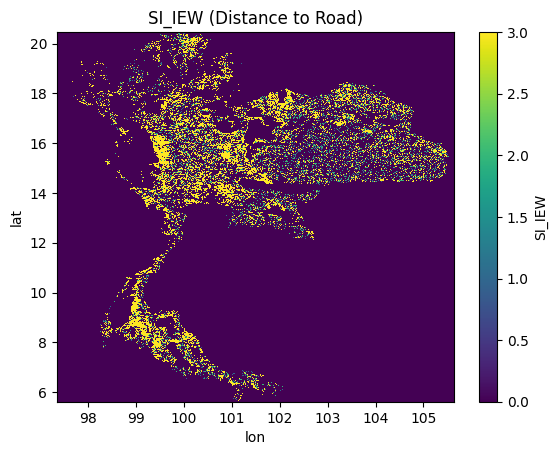

In [ ]:
plot_obj = xr_distancetoroad['SI_IEW'].plot(cmap='viridis')
plt.title('SI_IEW (Distance to Road)')
plt.show()